# Company-year sector and LSEG policy analysis

This notebook uses the cached Trucost–LSEG–FactSet matched panel. It checks sector/year coverage, calculates consecutive-year absolute-emissions and intensity changes, and models associations with LSEG policies in Electronic Technology and Producer Manufacturing. The descriptive Scope plots and broader policy-event analysis are in notebook 07.

Run from top to bottom with the working directory set to `notebooks/`. Year 2015 supplies the lag for 2016 outcomes; the ESG-complete analysis years are 2016–2024. Direct percentage reductions allow zero current emissions when the prior value is positive; log outcomes require both values to be positive. Tail trimming is configured below. Neither the HLM nor the policy-change model identifies a causal effect.


## 1. Setup

Use the completed matched panel; no raw-source parsing or fuzzy matching is repeated.


In [14]:
from pathlib import Path
import sys
import warnings

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

try:
    import statsmodels.formula.api as smf
    from statsmodels.base._penalties import PSD
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels is not installed. Run `pip install -r requirements.txt` before the HLM section.")

PROJECT_ROOT = Path("..").resolve()
MATCHED_PANEL_PATH = PROJECT_ROOT / "data/processed/cdp_trucost_factset_common/trucost_lseg_factset_matched_2015_2025.csv.gz"
FACTSET_ROOT = PROJECT_ROOT / "data/raw/FactSet"

FOCUS_SECTORS = ["Electronic Technology", "Producer Manufacturing"]
# Include 2015 only as the lag year needed to calculate a 2016 change.
ANALYSIS_YEARS = set(range(2015, 2025))
PANEL_YEARS = set(range(2015, 2025))
OUTCOME_YEARS = set(range(2016, 2025))
ESG_COMPLETE_ANALYSIS_YEARS = set(range(2016, 2025))
COMPANY_ID = "trucost_company_id"
# Scope 2 location- and market-based measures are distinct; Scope 3 is
# likewise retained as separate upstream and downstream outcomes.
RAW_EMISSION_COLUMNS = {
    "Scope 1": "scope_1_emissions",
    "Scope 2 location-based": "scope_2_location_based_emissions",
    "Scope 2 market-based": "scope_2_market_based_emissions",
    "Scope 3 upstream": "scope_3_upstream_emissions",
    "Scope 3 downstream": "scope_3_downstream_emissions",
}
EMISSION_COLUMNS = RAW_EMISSION_COLUMNS.copy()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
print("Project root:", PROJECT_ROOT)
print("Panel years (includes lag year):", f"{min(ANALYSIS_YEARS)}–{max(ANALYSIS_YEARS)}")
print("ESG-complete outcome years:", f"{min(ESG_COMPLETE_ANALYSIS_YEARS)}–{max(ESG_COMPLETE_ANALYSIS_YEARS)}")
print("Focus sectors:", FOCUS_SECTORS)


Project root: C:\Users\scelik\OneDrive - Tilburg University\TRACE3Code
Panel years (includes lag year): 2015–2024
ESG-complete outcome years: 2016–2024
Focus sectors: ['Electronic Technology', 'Producer Manufacturing']


## 2. Build the company-year sector panel

The cached matched panel is already unique at the Trucost-company/year level. The only remaining enrichment is the FactSet sector reference lookup used to attach `SECTOR_DESC`.


In [15]:
if not MATCHED_PANEL_PATH.exists():
    raise FileNotFoundError(
        f"Matched panel not found: {MATCHED_PANEL_PATH}. Build it with common_companies_by_year.py first."
    )
base = pd.read_csv(MATCHED_PANEL_PATH, compression="gzip", low_memory=False)
base["year"] = pd.to_numeric(base["year"], errors="coerce").astype("Int64")
base = base[base["year"].isin(ANALYSIS_YEARS)].copy()
required_base = ["year", COMPANY_ID, "factset_entity_id", *RAW_EMISSION_COLUMNS.values()]
missing_base = [column for column in required_base if column not in base.columns]
# if missing_base:
#     market_scope_column = RAW_EMISSION_COLUMNS["Scope 2 market-based"]
#     if market_scope_column in missing_base:
#         raise KeyError(
#             "The matched panel predates the separate Scope 2 market-based extraction. "
#             "Rebuild data/processed/trucost_lseg_factset_matched_2015_2025.csv.gz "
#             "with common_companies_by_year.py --refresh-matched-panel-cache, then rerun this notebook. "
#             f"Missing columns: {missing_base}"
#         )
#     raise KeyError(f"Matched panel is missing required columns: {missing_base}")
duplicate_company_year = base.duplicated([COMPANY_ID, "year"], keep=False)
if duplicate_company_year.any():
    print(f"Resolving {duplicate_company_year.sum():,} duplicate matched rows by match score and stable identifier order.")
    base = (
        base.sort_values(
            [COMPANY_ID, "year", "lseg_name_score", "factset_name_score", "isin", "lseg_instrument"],
            ascending=[True, True, False, False, True, True],
            na_position="last",
        )
        .drop_duplicates([COMPANY_ID, "year"], keep="first")
        .reset_index(drop=True)
    )

entity_sector = pd.read_csv(
    FACTSET_ROOT / "sym_entity_v1_full_12328/sym_entity_sector.txt",
    sep="|", quotechar='"', dtype=str,
    usecols=["FACTSET_ENTITY_ID", "INDUSTRY_CODE", "SECTOR_CODE"],
)
sector_map = pd.read_csv(
    FACTSET_ROOT / "ref_hub_v2_full_3565/factset_sector_map.txt",
    sep="|", quotechar='"', dtype=str,
)
industry_map = pd.read_csv(
    FACTSET_ROOT / "ref_hub_v2_full_3565/factset_industry_map.txt",
    sep="|", quotechar='"', dtype=str,
).rename(columns={"FACTSET_SECTOR_CODE": "SECTOR_CODE_FROM_INDUSTRY"})
entity_sector = entity_sector.merge(
    industry_map, left_on="INDUSTRY_CODE", right_on="FACTSET_INDUSTRY_CODE", how="left"
)
entity_sector["SECTOR_CODE_FINAL"] = entity_sector["SECTOR_CODE"].where(
    entity_sector["SECTOR_CODE"].notna() & entity_sector["SECTOR_CODE"].ne(""),
    entity_sector["SECTOR_CODE_FROM_INDUSTRY"],
)
sector_lookup = (
    entity_sector.merge(
        sector_map, left_on="SECTOR_CODE_FINAL", right_on="FACTSET_SECTOR_CODE", how="left"
    )[["FACTSET_ENTITY_ID", "FACTSET_SECTOR_DESC", "FACTSET_INDUSTRY_DESC"]]
    .rename(columns={"FACTSET_SECTOR_DESC": "SECTOR_DESC", "FACTSET_INDUSTRY_DESC": "INDUSTRY_DESC"})
    .drop_duplicates("FACTSET_ENTITY_ID")
)
base = base.merge(
    sector_lookup, left_on="factset_entity_id", right_on="FACTSET_ENTITY_ID", how="left"
).drop(columns="FACTSET_ENTITY_ID")
print(f"Matched panel: {len(base):,} company-year rows; {base[COMPANY_ID].nunique():,} companies")
print(f"FactSet sector coverage: {base['SECTOR_DESC'].notna().mean():.1%}")
#display(base[["year", COMPANY_ID, "SECTOR_DESC", "INDUSTRY_DESC", *EMISSION_COLUMNS.values()]].head())


Resolving 20 duplicate matched rows by match score and stable identifier order.
Matched panel: 89,228 company-year rows; 12,680 companies
FactSet sector coverage: 97.7%


## 3. Use retained LSEG fields from the matched panel

The matched panel already contains the retained LSEG financial, ESG, and policy fields selected by `common_companies_by_year.py`. No raw LSEG file is read and no matching is repeated.


In [16]:
LSEG_POLICY_FIELDS = [
    "policy_emissions", "policy_energy_efficiency",
    "policy_environmental_supply_chain", "policy_sustainable_packaging",
    "policy_clean_energy", "take_back_recycling", "hybrid_vehicles",
    "eco_design", "sustainability_reporting", "target_energy_efficiency",
    "transition_plan_offsets", "internal_carbon_policy",
    "environmental_supply_chain_monitoring",
    "environmental_supply_chain_management",
    "environmental_materials_sourcing", "iso_14000_or_ems",
]
missing_lseg_fields = [column for column in LSEG_POLICY_FIELDS if column not in base.columns]
if missing_lseg_fields:
    raise KeyError(f"Matched panel is missing retained LSEG fields: {missing_lseg_fields}")
print(f"Using {len(LSEG_POLICY_FIELDS)} retained LSEG policy fields from the matched panel.")


Using 16 retained LSEG policy fields from the matched panel.


lseg_match_method
year+normalized_name    77629
year+fuzzy_name         11599
Name: matched records, dtype: int64
Analysis panel: 89,228 matched company-year rows
FactSet sector coverage: 97.7%


,year,sector,observations,unique_companies
0,2015,Commercial Services,126,126
1,2015,Communications,95,95
2,2015,Consumer Durables,163,163
3,2015,Consumer Non-Durables,255,255
4,2015,Consumer Services,214,214
...,...,...,...,...
200,2024,Producer Manufacturing,823,823
201,2024,Retail Trade,418,418
202,2024,Technology Services,723,723
203,2024,Transportation,338,338


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
SECTOR_DESC,,,,,,,,,,
Commercial Services,126,243,255,294,305,326,337,341,338,337
Communications,95,125,128,138,140,141,134,143,135,139
Consumer Durables,163,253,262,288,295,314,313,328,327,324
Consumer Non-Durables,255,360,363,387,396,414,422,434,433,436
Consumer Services,214,344,346,376,372,401,393,406,406,413
Distribution Services,104,170,170,192,200,208,209,211,215,211
Electronic Technology,253,485,498,529,571,595,614,634,646,645
Energy Minerals,177,228,232,251,252,254,255,255,252,253
Finance,979,1732,1779,1957,1963,2076,2075,2105,2082,2160


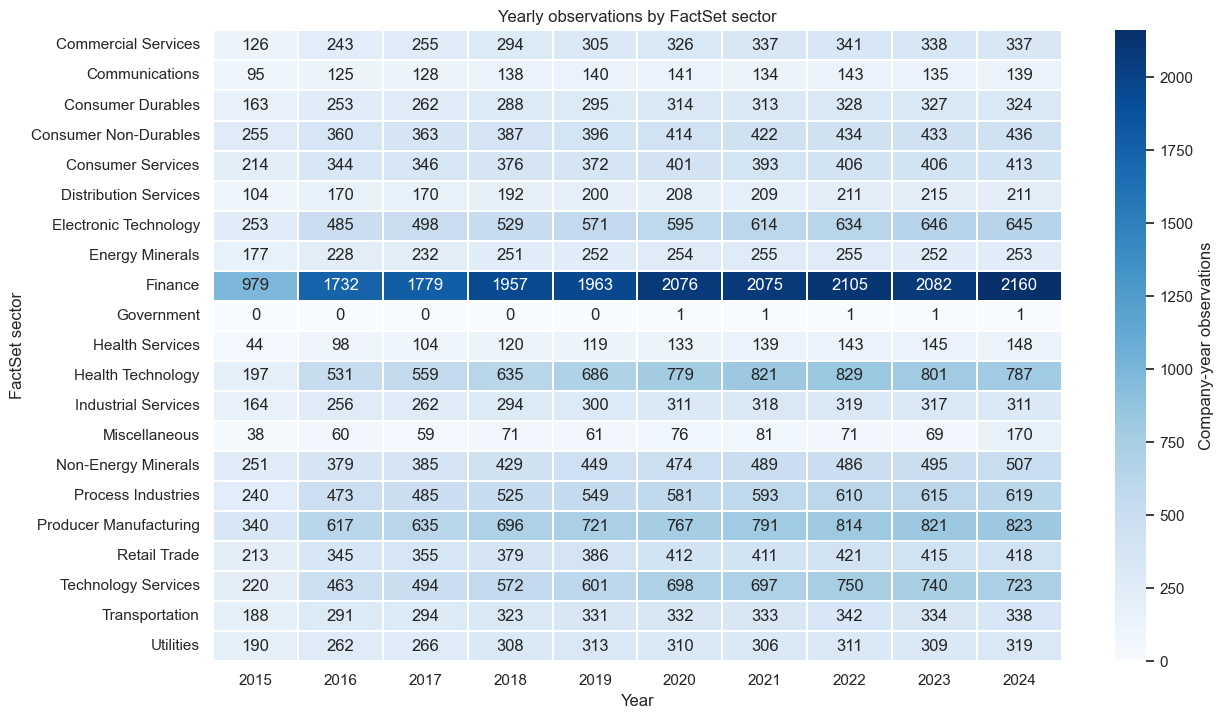

,year,trucost_company_id,SECTOR_DESC,lseg_revenue,number_of_employees,policy_adoption_rate
0,2015,18511.0,Miscellaneous,1.126348e+09,277.0,0.4
1,2016,18511.0,Miscellaneous,1.260834e+09,271.0,0.2
2,2017,18511.0,Miscellaneous,1.165863e+09,276.0,0.2
3,2018,18511.0,Miscellaneous,1.755046e+09,281.0,0.4
4,2019,18511.0,Miscellaneous,1.838771e+09,241.0,0.4375


In [17]:
def as_binary_flag(values: pd.Series) -> pd.Series:
    # Return 1/0/NA from boolean, numeric, or common text LSEG flags.
    if pd.api.types.is_bool_dtype(values):
        return values.astype("Float64")
    numeric = pd.to_numeric(values, errors="coerce")
    result = pd.Series(pd.NA, index=values.index, dtype="Float64")
    result[numeric.isin([0, 1])] = numeric[numeric.isin([0, 1])]
    text = values.astype("string").str.strip().str.casefold()
    result[text.isin({"true", "yes", "y", "1"})] = 1.0
    result[text.isin({"false", "no", "n", "0"})] = 0.0
    return result

def first_available(frame: pd.DataFrame, candidates: list[str]) -> pd.Series:
    present = [column for column in candidates if column in frame.columns]
    if not present:
        return pd.Series(np.nan, index=frame.index)
    return pd.concat([pd.to_numeric(frame[column], errors="coerce") for column in present], axis=1).bfill(axis=1).iloc[:, 0]

LSEG_STANDARD_FIELDS = {}  # Financial and ESG fields are already standardized in `base`.
# Trucost–LSEG–FactSet matching is complete in the cached `base` panel.
base["lseg_record_matched"] = True
print(base["lseg_match_method"].value_counts(dropna=False).rename("matched records"))

for output_name, candidates in LSEG_STANDARD_FIELDS.items():
    base[output_name] = first_available(base, candidates)
policy_fields = [column for column in LSEG_POLICY_FIELDS if column in base.columns]
for column in policy_fields:
    base[column] = as_binary_flag(base[column])
base["policy_flags_reported"] = base[policy_fields].notna().sum(axis=1)
base["policy_score"] = base[policy_fields].sum(axis=1, min_count=1)
base["policy_adoption_rate"] = (
    base["policy_score"] / base["policy_flags_reported"].replace(0, np.nan)
)
base["internal_carbon_pricing"] = base["internal_carbon_policy"]
analysis_panel = base.copy()

# Report the number of retained company-year observations in every FactSet
# sector and year. `observations` counts rows; `unique_companies` is shown
# alongside it as a diagnostic for accidental duplicate company-years.
sector_year_observations = (
    analysis_panel.dropna(subset=["SECTOR_DESC"])
    .groupby(["year", "SECTOR_DESC"], as_index=False)
    .agg(
        observations=(COMPANY_ID, "size"),
        unique_companies=(COMPANY_ID, "nunique"),
    )
    .sort_values(["year", "SECTOR_DESC"])
    .reset_index(drop=True)
)
sector_year_observation_matrix = (
    sector_year_observations.pivot(
        index="SECTOR_DESC", columns="year", values="observations"
    )
    .fillna(0)
    .astype(int)
    .sort_index()
)

print(f"Analysis panel: {len(analysis_panel):,} matched company-year rows")
print(f"FactSet sector coverage: {analysis_panel['SECTOR_DESC'].notna().mean():.1%}")
display(sector_year_observations.rename(columns={"SECTOR_DESC": "sector"}))
display(sector_year_observation_matrix.style.set_caption("Company-year observations by FactSet sector and year"))

if not sector_year_observation_matrix.empty:
    fig_height = max(5, 0.35 * len(sector_year_observation_matrix))
    fig, ax = plt.subplots(figsize=(13, fig_height))
    sns.heatmap(
        sector_year_observation_matrix.astype(float), cmap="Blues", annot=True, fmt=".0f",
        linewidths=0.3, linecolor="white", cbar_kws={"label": "Company-year observations"}, ax=ax,
    )
    ax.set_title("Yearly observations by FactSet sector")
    ax.set_xlabel("Year")
    ax.set_ylabel("FactSet sector")
    plt.tight_layout()
    output_path = PROJECT_ROOT / "data" / "outputs" / "dataset_readers" / "yearly_observations_by_factset_sector.pdf"
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(output_path, bbox_inches="tight")
    plt.show()


display(analysis_panel[["year", COMPANY_ID, "SECTOR_DESC", "lseg_revenue", "number_of_employees", "policy_adoption_rate"]].head())


## 4. LSEG missingness by year after exclusions

Missingness is reported for the LSEG variables actually used in the model, not for fields configured for exclusion. The second table adds sector context for the two focal sectors.


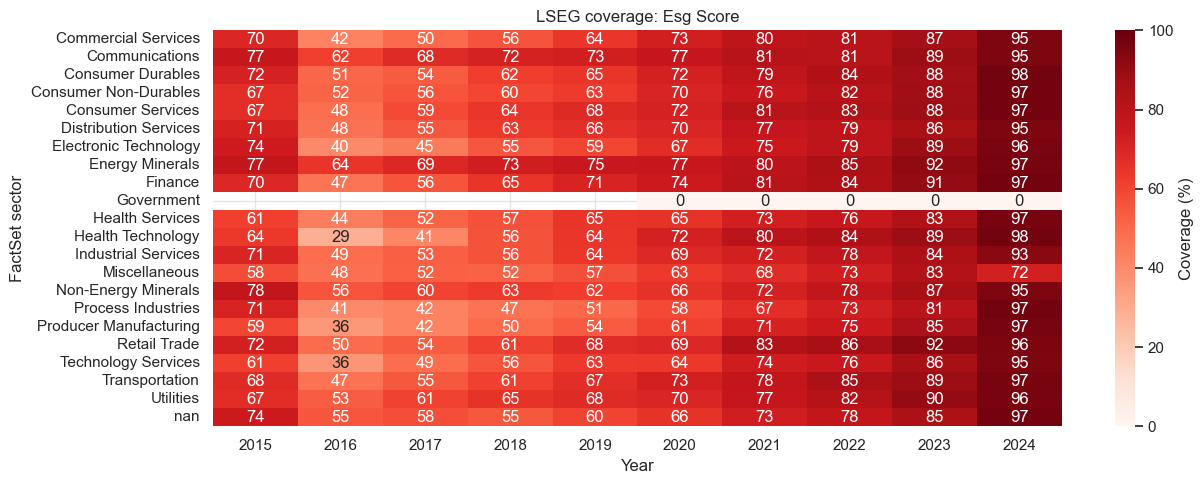

In [18]:
LSEG_MODEL_FIELDS = [
    # "lseg_revenue", "inventory_turnover", "number_of_employees", "gross_profit",
    "esg_score", #"policy_flags_reported", # "operating_profit",  "policy_score",
    #"policy_adoption_rate",# "internal_carbon_pricing",
]

# Missingness (%) by FactSet sector and year
lseg_coverage_by_year_sector = (
    analysis_panel
    .groupby(["SECTOR_DESC", "year"], dropna=False)[LSEG_MODEL_FIELDS]
    .agg(lambda values:  100 - values.isna().mean() * 100 )#values.isna().mean() * 100)
    .round(1)
)

# display(
#     lseg_missing_by_year_sector.style
#     .format("{:.1f}%")
#     .set_caption("LSEG missingness by FactSet sector and year")
# )

# One heatmap per retained LSEG variable
fig, axes = plt.subplots(
    nrows=len(LSEG_MODEL_FIELDS),
    figsize=(13, 5 * len(LSEG_MODEL_FIELDS)),
    squeeze=False,
)

for ax, field in zip(axes.flat, LSEG_MODEL_FIELDS):
    heatmap_data = (
        lseg_coverage_by_year_sector[field]
        .unstack("year")
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    sns.heatmap(
        heatmap_data,
        cmap="Reds",
        vmin=0,
        vmax=100,
        annot=True,
        fmt=".0f",
        ax=ax,
        cbar_kws={"label": "Coverage (%)"},
    )
    ax.set_title(f"LSEG coverage: {field.replace('_', ' ').title()}")
    ax.set_xlabel("Year")
    ax.set_ylabel("FactSet sector")

plt.tight_layout()

output_path = PROJECT_ROOT / "data" / "outputs" / "dataset_readers" / "coverage.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, bbox_inches="tight")
plt.show()

focus_lseg_coverage = (
    analysis_panel#[analysis_panel["SECTOR_DESC"].isin(FOCUS_SECTORS)]
    .groupby(["SECTOR_DESC", "year"])[LSEG_MODEL_FIELDS]
    .agg(lambda values: 100 - values.isna().mean() * 100)
    .round(1)
)
#display(focus_lseg_coverage[focus_lseg_coverage['policy_adoption_rate']>80].sort_values('policy_adoption_rate'))


### Export LSEG coverage to LaTeX

This cell writes the focal-sector coverage table.


In [19]:
from pathlib import Path

latex_table = (
    focus_lseg_coverage
    .rename(columns=lambda column: column.replace("_", " ").title())
    .to_latex(
        float_format=lambda value: f"{value:.1f}\\%",
        caption="LSEG variable coverage in focal sectors by year.",
        label="tab:focus_lseg_coverage",
        escape=False,
        multicolumn=True,
        multirow=True,
        column_format="ll" + "r" * len(focus_lseg_coverage.columns),
    )
)

output_path = PROJECT_ROOT / "data" / "outputs" / "dataset_readers" / "focus_lseg_coverage.tex"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(latex_table, encoding="utf-8")

5352

## 5. Emissions-reduction outcomes and tail screening

Changes are computed within company for consecutive years, then restricted to the ESG-complete sample.


In [20]:
# Build within-company annual absolute-emissions and intensity changes before restricting to outcome years.
reduction_panel = base.copy().sort_values([COMPANY_ID, "year"]).reset_index(drop=True)
reduction_panel["trucost_revenue"] = pd.to_numeric(reduction_panel["trucost_revenue"], errors="coerce")
reduction_panel["esg_score"] = pd.to_numeric(reduction_panel["esg_score"], errors="coerce")
previous_year = reduction_panel.groupby(COMPANY_ID)["year"].shift(1)
previous_revenue = reduction_panel.groupby(COMPANY_ID)["trucost_revenue"].shift(1)

LOG_REDUCTION_OUTCOMES = []  # Use only in regressions.
PCT_REDUCTION_OUTCOMES = []  # Use in every descriptive table and figure.
PCT_OUTCOME_TO_SCOPE = {}
PCT_OUTCOME_TO_BASIS = {}
SCOPE_COLUMNS = {
    "Scope 1": "scope_1_emissions",
    "Scope 2 location-based": "scope_2_location_based_emissions",
    #"Scope 2 market-based": "scope_2_market_based_emissions",
    "Scope 3 upstream": "scope_3_upstream_emissions",
    #"Scope 3 downstream": "scope_3_downstream_emissions",
}
for label, column in SCOPE_COLUMNS.items():
    scope_key = label.lower().replace(" ", "_").replace("-", "_")
    current_emissions = pd.to_numeric(reduction_panel[column], errors="coerce")
    previous_emissions = pd.to_numeric(reduction_panel.groupby(COMPANY_ID)[column].shift(1), errors="coerce")
    current_intensity = current_emissions.div(reduction_panel["trucost_revenue"])
    previous_intensity = previous_emissions.div(previous_revenue)
    valid_absolute_pct_pair = (
        current_emissions.ge(0) & previous_emissions.gt(0)
        & reduction_panel["year"].eq(previous_year + 1)
    )
    valid_intensity_pct_pair = (
        current_emissions.ge(0) & previous_emissions.gt(0)
        & reduction_panel["trucost_revenue"].gt(0) & previous_revenue.gt(0)
        & current_intensity.ge(0) & previous_intensity.gt(0)
        & reduction_panel["year"].eq(previous_year + 1)
    )
    reduction_definitions = {
        "Absolute emissions": (
            current_emissions, previous_emissions, valid_absolute_pct_pair,
        ),
        "Emissions intensity": (
            current_intensity, previous_intensity, valid_intensity_pct_pair,
        ),
    }
    for basis, (current_value, previous_value, valid_pct_pair) in reduction_definitions.items():
        basis_key = basis.lower().replace(" ", "_")
        valid_log_pair = valid_pct_pair & current_value.gt(0)
        log_outcome = f"{scope_key}_{basis_key}_log_reduction"
        pct_outcome = f"{scope_key}_{basis_key}_pct_reduction"
        reduction_panel[log_outcome] = (
            np.log(previous_value.where(valid_log_pair))
            - np.log(current_value.where(valid_log_pair))
        )
        reduction_panel[pct_outcome] = 100 * (
            1 - current_value.where(valid_pct_pair) / previous_value.where(valid_pct_pair)
        )
        LOG_REDUCTION_OUTCOMES.append(log_outcome)
        PCT_REDUCTION_OUTCOMES.append(pct_outcome)
        PCT_OUTCOME_TO_SCOPE[pct_outcome] = label
        PCT_OUTCOME_TO_BASIS[pct_outcome] = basis

# Model every generated Scope-by-basis log reduction; keep its direct percentage counterpart for diagnostics.
REDUCTION_OUTCOMES = LOG_REDUCTION_OUTCOMES.copy()
REDUCTION_PERCENT_OUTCOMES = {
    outcome: outcome.replace("_log_reduction", "_pct_reduction")
    for outcome in REDUCTION_OUTCOMES
}

# Restrict the descriptive and regression samples to ESG-complete outcome years.
reduction_panel = reduction_panel[
    reduction_panel["year"].isin(OUTCOME_YEARS) & reduction_panel["esg_score"].notna()
].copy()
reduction_long = reduction_panel.melt(
    id_vars=["year", COMPANY_ID, "SECTOR_DESC"],
    value_vars=PCT_REDUCTION_OUTCOMES,
    var_name="reduction_measure", value_name="pct_reduction",
).dropna(subset=["pct_reduction"])
reduction_long["scope"] = reduction_long["reduction_measure"].map(PCT_OUTCOME_TO_SCOPE)
reduction_long["reduction_basis"] = reduction_long["reduction_measure"].map(PCT_OUTCOME_TO_BASIS)
reduction_long = reduction_long.drop(columns="reduction_measure")


### Inspect and trim extreme reductions

The untrimmed measures remain available for sensitivity checks.


In [21]:
# Extreme percentage changes are almost always driven by a very small prior-year
# intensity or revenue denominator.  Keep the raw panel for auditability, then
# remove the outer 1% in each tail within every scope and reduction basis.
# Change these quantiles (or set REMOVE_REDUCTION_OUTLIERS=False) for sensitivity checks.
REMOVE_REDUCTION_OUTLIERS = True
REDUCTION_OUTLIER_QUANTILES = (0.01, 0.99)
reduction_long_raw = reduction_long.copy()
reduction_outlier_bounds = (
    reduction_long_raw.groupby(["scope", "reduction_basis"])["pct_reduction"]
    .quantile(list(REDUCTION_OUTLIER_QUANTILES)).unstack()
    .rename(columns={REDUCTION_OUTLIER_QUANTILES[0]: "lower_bound", REDUCTION_OUTLIER_QUANTILES[1]: "upper_bound"})
    .reset_index()
)
reduction_long = reduction_long_raw.merge(
    reduction_outlier_bounds, on=["scope", "reduction_basis"], how="left", validate="many_to_one"
)
reduction_long["is_reduction_outlier"] = (
    reduction_long["pct_reduction"].lt(reduction_long["lower_bound"])
    | reduction_long["pct_reduction"].gt(reduction_long["upper_bound"])
)
reduction_outlier_summary = (
    reduction_long.groupby(["scope", "reduction_basis"], as_index=False)
    .agg(
        lower_bound=("lower_bound", "first"), upper_bound=("upper_bound", "first"),
        observations_before=("pct_reduction", "size"),
        observations_removed=("is_reduction_outlier", "sum"),
    )
)
reduction_outlier_summary["observations_after"] = (
    reduction_outlier_summary["observations_before"] - reduction_outlier_summary["observations_removed"]
)
display(reduction_outlier_summary)
if REMOVE_REDUCTION_OUTLIERS:
    reduction_long = reduction_long.loc[~reduction_long["is_reduction_outlier"]].copy()
reduction_long = reduction_long.drop(columns=["lower_bound", "upper_bound"])

reduction_sector_year = (
    reduction_long.dropna(subset=["SECTOR_DESC"])
    .groupby(["year", "SECTOR_DESC", "scope", "reduction_basis"], as_index=False)
    .agg(
        mean_pct_reduction=("pct_reduction", "mean"),
        median_pct_reduction=("pct_reduction", "median"),
        observations=("pct_reduction", "size"),
        companies=(COMPANY_ID, "nunique"),
    )
)


,scope,reduction_basis,lower_bound,upper_bound,observations_before,observations_removed,observations_after
0,Scope 1,Absolute emissions,-776.333510,95.486828,57848,1158,56690
1,Scope 1,Emissions intensity,-530.431031,94.805462,57848,1158,56690
2,Scope 2 location-based,Absolute emissions,-833.345277,90.952036,58007,1162,56845
3,Scope 2 location-based,Emissions intensity,-595.579307,87.907939,58007,1162,56845
4,Scope 3 upstream,Absolute emissions,-256.630669,71.670567,58038,1162,56876
5,Scope 3 upstream,Emissions intensity,-58.380748,41.384514,58038,1162,56876


## 6. Policy-specific hierarchical models

Each policy is fitted separately with common controls. Results are associations, not treatment effects.


In [22]:
# A small positive-definite covariance penalty prevents the company random
# intercept variance from collapsing exactly to zero at the likelihood boundary.
HLM_COVARIANCE_PENALTY = 1e-3

# These LSEG characteristics are included in every policy-specific model.
HLM_COVARIATES = [
    "lseg_revenue", "number_of_employees", "inventory_turnover", "esg_score",
]
hlm_panel = reduction_panel[reduction_panel["SECTOR_DESC"].isin(FOCUS_SECTORS)].copy()

if "lseg_revenue" not in hlm_panel.columns:
    raise KeyError("The matched panel does not contain LSEG revenue. Refresh the matched LSEG fields first.")
hlm_panel["lseg_revenue"] = pd.to_numeric(hlm_panel["lseg_revenue"], errors="coerce")
print(f"LSEG revenue coverage in focal sectors: {hlm_panel['lseg_revenue'].notna().sum():,} / {len(hlm_panel):,} rows")

for column in ["lseg_revenue", "number_of_employees"]:
    values = pd.to_numeric(hlm_panel[column], errors="coerce")
    hlm_panel[f"log_{column}"] = np.log1p(values.where(values >= 0))
for column in ["log_lseg_revenue", "log_number_of_employees", "inventory_turnover", "esg_score"]:
    values = pd.to_numeric(hlm_panel[column], errors="coerce")
    std = values.std()
    hlm_panel[f"z_{column}"] = (values - values.mean()) / std if pd.notna(std) and std > 0 else np.nan

HLM_CONTROL_PREDICTORS = [
    "z_log_lseg_revenue", "z_log_number_of_employees", "z_inventory_turnover", "z_esg_score",
]
# Estimate each LSEG policy in its own HLM rather than combining the 16
# potentially correlated policies in one specification.
HLM_POLICY_FIELDS = [column for column in LSEG_POLICY_FIELDS if column in hlm_panel.columns]
HLM_POLICY_PREDICTORS = {}
policy_model_coverage_rows = []
for column in HLM_POLICY_FIELDS:
    values = pd.to_numeric(hlm_panel[column], errors="coerce")
    observed_rows = int(values.notna().sum())
    observed_companies = int(hlm_panel.loc[values.notna(), COMPANY_ID].nunique())
    levels = int(values.dropna().nunique())
    std = values.std()
    predictor = f"z_{column}"
    estimable = observed_rows >= 100 and observed_companies >= 20 and levels >= 2 and pd.notna(std) and std > 0
    if estimable:
        hlm_panel[predictor] = (values - values.mean()) / std
        HLM_POLICY_PREDICTORS[column] = predictor
    policy_model_coverage_rows.append({
        "policy_field": column, "observed_rows": observed_rows,
        "observed_companies": observed_companies, "levels": levels, "estimable": estimable,
    })
policy_model_coverage = pd.DataFrame(policy_model_coverage_rows)

# Kept as an alias for cells that refer to the common control specification.
HLM_PREDICTORS = HLM_CONTROL_PREDICTORS
print(f"Focal-sector panel: {len(hlm_panel):,} rows, {hlm_panel[COMPANY_ID].nunique():,} companies")
print("Common control predictors:", HLM_CONTROL_PREDICTORS)
print(f"Estimable separate-policy specifications: {len(HLM_POLICY_PREDICTORS)} / {len(HLM_POLICY_FIELDS)}")
display(policy_model_coverage)


LSEG revenue coverage in focal sectors: 7,949 / 7,974 rows
Focal-sector panel: 7,974 rows, 1,557 companies
Common control predictors: ['z_log_lseg_revenue', 'z_log_number_of_employees', 'z_inventory_turnover', 'z_esg_score']
Estimable separate-policy specifications: 15 / 16


,policy_field,observed_rows,observed_companies,levels,estimable
0,policy_emissions,7962,1557,2,True
1,policy_energy_efficiency,7961,1557,2,True
2,policy_environmental_supply_chain,7963,1557,2,True
3,policy_sustainable_packaging,7957,1557,2,True
4,policy_clean_energy,7957,1557,2,True
5,take_back_recycling,7957,1557,2,True
6,hybrid_vehicles,7957,1557,2,True
7,eco_design,7959,1557,2,True
8,sustainability_reporting,7964,1557,2,True
9,target_energy_efficiency,7940,1549,2,True


### Correlation and variance-inflation diagnostics


Pairs with |Spearman rho| >= 0.70: 3


,predictor_1,predictor_2,spearman_rho,abs_spearman_rho
0,Log LSEG revenue,Log employees,0.918881,0.918881
138,Policy Environmental Supply Chain,Environmental Supply Chain Management,0.769694,0.769694
293,Scope 2 Location Based Absolute Emissions annu...,Scope 2 Location Based Emissions Intensity ann...,0.702421,0.702421


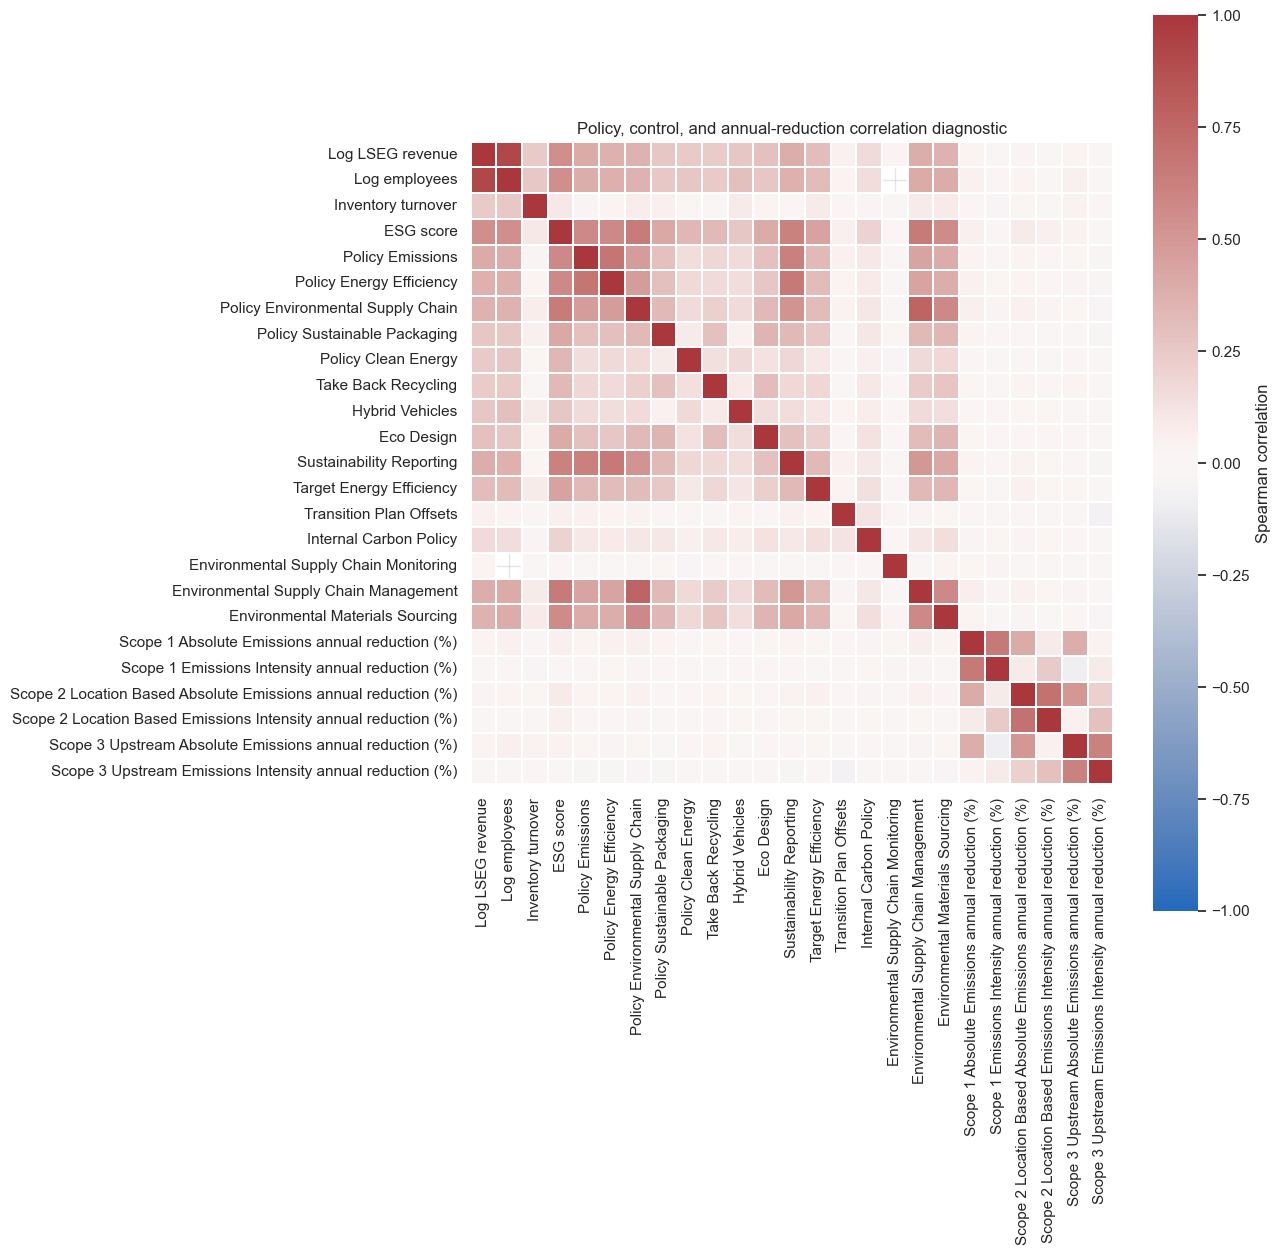

C:\Users\scelik\AppData\Local\Temp\ipykernel_9384\2114660353.py:62: RuntimeWarning: All-NaN slice encountered
  "max_control_vif": np.nanmax(vif_values[:-1]),


,policy_field,n_complete_cases,policy_vif,max_control_vif,vif_flag
13,environmental_supply_chain_management,6329,1.692246,5.742167,ok
2,policy_environmental_supply_chain,6331,1.647710,5.737436,ok
8,sustainability_reporting,6332,1.524435,5.740165,ok
14,environmental_materials_sourcing,6328,1.477905,5.736556,ok
0,policy_emissions,6330,1.439025,5.736901,ok
1,policy_energy_efficiency,6329,1.435629,5.739520,ok
9,target_energy_efficiency,6324,1.249758,5.753150,ok
3,policy_sustainable_packaging,6326,1.207933,5.762353,ok
7,eco_design,6328,1.191379,5.757893,ok
5,take_back_recycling,6327,1.171524,5.765229,ok


Random-intercept covariance penalty: 0.001


In [23]:
# Correlation is descriptive here: policies are fitted separately, not jointly.
# Include the three reduction outcomes so high policy--outcome associations are visible.
# Spearman correlations are robust to skewed financial variables and binary flags.
CORRELATION_WARNING_THRESHOLD = 0.70
VIF_WARNING_THRESHOLD = 5.0
SCOPE_REDUCTION_OUTCOMES = [
    outcome for outcome in REDUCTION_PERCENT_OUTCOMES.values() if outcome in hlm_panel.columns
]
correlation_variables = [
    *HLM_CONTROL_PREDICTORS, *HLM_POLICY_PREDICTORS.values(), *SCOPE_REDUCTION_OUTCOMES,
]
predictor_labels = {
    "z_log_lseg_revenue": "Log LSEG revenue",
    "z_log_number_of_employees": "Log employees",
    "z_inventory_turnover": "Inventory turnover",
    "z_esg_score": "ESG score",
    **{predictor: field.replace("_", " ").title() for field, predictor in HLM_POLICY_PREDICTORS.items()},
    **{outcome: outcome.replace("_pct_reduction", "").replace("_", " ").title() + " annual reduction (%)" for outcome in SCOPE_REDUCTION_OUTCOMES},
}
correlation_input = hlm_panel[correlation_variables].apply(pd.to_numeric, errors="coerce")
spearman_correlation = correlation_input.corr(method="spearman", min_periods=50)
upper_triangle = spearman_correlation.where(
    np.triu(np.ones(spearman_correlation.shape, dtype=bool), k=1)
)
high_correlation_pairs = (
    upper_triangle.stack().rename("spearman_rho").reset_index()
    .rename(columns={"level_0": "predictor_1", "level_1": "predictor_2"})
)
high_correlation_pairs["abs_spearman_rho"] = high_correlation_pairs["spearman_rho"].abs()
high_correlation_pairs = high_correlation_pairs.query("abs_spearman_rho >= @CORRELATION_WARNING_THRESHOLD")
high_correlation_pairs["predictor_1"] = high_correlation_pairs["predictor_1"].map(predictor_labels)
high_correlation_pairs["predictor_2"] = high_correlation_pairs["predictor_2"].map(predictor_labels)
high_correlation_pairs = high_correlation_pairs.sort_values("abs_spearman_rho", ascending=False)
print(f"Pairs with |Spearman rho| >= {CORRELATION_WARNING_THRESHOLD:.2f}: {len(high_correlation_pairs):,}")
display(high_correlation_pairs)

fig, ax = plt.subplots(figsize=(max(10, 0.52 * len(correlation_variables)), max(8, 0.52 * len(correlation_variables))))
sns.heatmap(
    spearman_correlation.rename(index=predictor_labels, columns=predictor_labels),
    cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.3,
    cbar_kws={"label": "Spearman correlation"}, ax=ax,
)
ax.set_title("Policy, control, and annual-reduction correlation diagnostic")
plt.tight_layout()
plt.show()

# VIF is calculated within each actual policy specification: common controls + one policy.
vif_rows = []
for policy_field, policy_predictor in HLM_POLICY_PREDICTORS.items():
    vif_data = hlm_panel[[*HLM_CONTROL_PREDICTORS, policy_predictor]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(vif_data) < 100:
        continue
    correlation_matrix = vif_data.corr().to_numpy()
    try:
        vif_values = np.diag(np.linalg.inv(correlation_matrix))
    except np.linalg.LinAlgError:
        vif_values = np.full(len(vif_data.columns), np.nan)
    vif_rows.append({
        "policy_field": policy_field,
        "n_complete_cases": len(vif_data),
        "policy_vif": vif_values[-1],
        "max_control_vif": np.nanmax(vif_values[:-1]),
    })
policy_vif_diagnostics = pd.DataFrame(vif_rows, columns=[
    "policy_field", "n_complete_cases", "policy_vif", "max_control_vif",
])
if policy_vif_diagnostics.empty:
    print("No policy specification has enough complete cases for VIF diagnostics.")
else:
    policy_vif_diagnostics = policy_vif_diagnostics.sort_values("policy_vif", ascending=False)
    policy_vif_diagnostics["vif_flag"] = np.select(
        [policy_vif_diagnostics["policy_vif"] >= 10, policy_vif_diagnostics["policy_vif"] >= VIF_WARNING_THRESHOLD],
        ["high (>=10)", "review (>=5)"], default="ok",
    )
    display(policy_vif_diagnostics)
print(f"Random-intercept covariance penalty: {HLM_COVARIANCE_PENALTY:g}")


In [24]:
# A singular or boundary random intercept does not support HLM inference.
# Keep these fits in a diagnostic log, not in the coefficient tables.
HLM_MIN_ICC = 1e-4
HLM_FIT_DIAGNOSTICS = []

def fit_reduction_hlm(outcome: str, policy_field: str):
    if not HAS_STATSMODELS:
        return None, pd.DataFrame()
    policy_predictor = HLM_POLICY_PREDICTORS.get(policy_field)
    if policy_predictor is None:
        return None, pd.DataFrame()
    model_predictors = [*HLM_CONTROL_PREDICTORS, policy_predictor]
    model_data = hlm_panel[[outcome, COMPANY_ID, "year", "SECTOR_DESC", *model_predictors]].copy()
    for column in [outcome, COMPANY_ID, "year", *model_predictors]:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")
    model_data["SECTOR_DESC"] = model_data["SECTOR_DESC"].astype("string")
    model_data = model_data.dropna().copy()
    n_companies = int(model_data[COMPANY_ID].nunique())
    diagnostic = {
        "policy_field": policy_field, "outcome": outcome,
        "n_rows": len(model_data), "n_companies": n_companies,
        "status": "", "reason": "", "random_intercept_variance": np.nan,
        "icc": np.nan, "warnings": "",
    }
    if n_companies < 20 or len(model_data) < 100:
        diagnostic.update(status="skipped", reason="insufficient_complete_cases")
        HLM_FIT_DIAGNOSTICS.append(diagnostic)
        return None, pd.DataFrame()
    model_data[COMPANY_ID] = model_data[COMPANY_ID].astype("int64")
    model_data["year"] = model_data["year"].astype("int64")
    model_data["SECTOR_DESC"] = model_data["SECTOR_DESC"].astype(str)
    formula = f"{outcome} ~ {' + '.join(model_predictors)} + C(year) + C(SECTOR_DESC)"
    try:
        # Warnings are recorded per model and summarized below, never silently
        # dismissed. They are too repetitive to print dozens of times.
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            result = smf.mixedlm(
                formula, data=model_data, groups=model_data[COMPANY_ID]
            ).fit(
                reml=False, method="lbfgs", maxiter=300,
                cov_pen=PSD(HLM_COVARIANCE_PENALTY), disp=False,
            )
            confidence = result.conf_int()
            coefficients = result.params
            standard_errors = result.bse
            p_values = result.pvalues
    except Exception as exc:
        diagnostic.update(status="failed", reason=f"{type(exc).__name__}: {exc}")
        HLM_FIT_DIAGNOSTICS.append(diagnostic)
        return None, pd.DataFrame()

    warning_messages = sorted({str(item.message) for item in caught})
    diagnostic["warnings"] = " | ".join(warning_messages)
    random_variance = float(np.asarray(result.cov_re, dtype=float)[0, 0])
    residual_variance = float(result.scale)
    icc = random_variance / (random_variance + residual_variance) if (
        np.isfinite(random_variance) and np.isfinite(residual_variance)
        and random_variance + residual_variance > 0
    ) else np.nan
    diagnostic["random_intercept_variance"] = random_variance
    diagnostic["icc"] = icc

    unstable_warning = any(
        phrase in message.lower()
        for message in warning_messages
        for phrase in (
            "covariance is singular", "hessian matrix", "boundary of the parameter",
            "invalid value encountered", "failed to converge",
        )
    )
    policy_inference_finite = (
        policy_predictor in coefficients.index
        and np.isfinite(coefficients.get(policy_predictor, np.nan))
        and np.isfinite(standard_errors.get(policy_predictor, np.nan))
        and np.isfinite(p_values.get(policy_predictor, np.nan))
    )
    if not result.converged or unstable_warning or not policy_inference_finite or (
        pd.isna(icc) or icc < HLM_MIN_ICC
    ):
        reasons = []
        if not result.converged:
            reasons.append("not_converged")
        if unstable_warning:
            reasons.append("singular_boundary_or_hessian_warning")
        if not policy_inference_finite:
            reasons.append("nonfinite_policy_inference")
        if pd.isna(icc) or icc < HLM_MIN_ICC:
            reasons.append("near_zero_or_invalid_random_intercept_variance")
        diagnostic.update(status="excluded", reason="; ".join(reasons))
        HLM_FIT_DIAGNOSTICS.append(diagnostic)
        return None, pd.DataFrame()

    diagnostic.update(status="accepted", reason="")
    HLM_FIT_DIAGNOSTICS.append(diagnostic)
    table = pd.DataFrame({
        "outcome": outcome,
        "term": coefficients.index,
        "coefficient": coefficients.values,
        "std_error": standard_errors.values,
        "p_value": p_values.values,
        "ci_low": confidence.iloc[:, 0].values,
        "ci_high": confidence.iloc[:, 1].values,
        "n_rows": len(model_data),
        "n_companies": n_companies,
        "policy_field": policy_field,
        "policy_predictor": policy_predictor,
        "estimator": "mixedlm",
        "random_intercept_variance": random_variance,
        "icc": icc,
    })
    table["is_policy_term"] = table["term"].eq(policy_predictor)
    return result, table

# Result objects retain their design matrices and can consume substantial memory across
# policy fields x Scope-by-basis outcomes. Keep compact coefficient tables by default.
RUN_MIXEDLM = True  # Set False to run only the faster company-clustered OLS alternative.
STORE_HLM_RESULTS = False
hlm_results = {} if STORE_HLM_RESULTS else None
hlm_tables = []
if RUN_MIXEDLM:
    for policy_field in HLM_POLICY_PREDICTORS:
        for outcome in REDUCTION_OUTCOMES:
            result, table = fit_reduction_hlm(outcome, policy_field)
            if STORE_HLM_RESULTS:
                hlm_results[(policy_field, outcome)] = result
            if not table.empty:
                hlm_tables.append(table)

hlm_fit_diagnostics = pd.DataFrame(HLM_FIT_DIAGNOSTICS)
if not hlm_fit_diagnostics.empty:
    print("MixedLM fit status by specification:")
    display(hlm_fit_diagnostics.groupby(["status", "reason"], dropna=False).size().rename("models"))
    display(hlm_fit_diagnostics.loc[
        hlm_fit_diagnostics["status"].ne("accepted"),
        ["policy_field", "outcome", "n_rows", "n_companies", "reason", "icc", "warnings"],
    ])
    print("Excluded HLM fits are not plotted or interpreted; compare the company-clustered OLS estimates below.")

if hlm_tables:
    hlm_coefficients = pd.concat(hlm_tables, ignore_index=True)
    policy_hlm_effects = hlm_coefficients[hlm_coefficients["is_policy_term"]].copy()
    display(policy_hlm_effects.sort_values(["policy_field", "outcome"]))
elif RUN_MIXEDLM:
    hlm_coefficients = pd.DataFrame()
    policy_hlm_effects = pd.DataFrame()
    print("No stable policy-specific HLM was retained. Inspect the fit diagnostics and the company-clustered OLS results below.")
else:
    hlm_coefficients = pd.DataFrame()
    policy_hlm_effects = pd.DataFrame()
    print("MixedLM skipped; running the company-clustered OLS alternative only.")

# Robustness model: the outcome is already a one-year log difference, so a pooled
# OLS model with company-clustered standard errors is a useful faster alternative.
# It retains year and sector fixed effects but does not impose a random-intercept distribution.
RUN_CLUSTERED_OLS_ROBUSTNESS = True

def fit_reduction_clustered_ols(outcome: str, policy_field: str):
    if not HAS_STATSMODELS:
        return None, pd.DataFrame()
    policy_predictor = HLM_POLICY_PREDICTORS.get(policy_field)
    if policy_predictor is None:
        return None, pd.DataFrame()
    model_predictors = [*HLM_CONTROL_PREDICTORS, policy_predictor]
    model_data = hlm_panel[[outcome, COMPANY_ID, "year", "SECTOR_DESC", *model_predictors]].copy()
    for column in [outcome, COMPANY_ID, "year", *model_predictors]:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")
    model_data["SECTOR_DESC"] = model_data["SECTOR_DESC"].astype("string")
    model_data = model_data.dropna().copy()
    if model_data[COMPANY_ID].nunique() < 20 or len(model_data) < 100:
        return None, pd.DataFrame()
    model_data[COMPANY_ID] = model_data[COMPANY_ID].astype("int64")
    model_data["year"] = model_data["year"].astype("int64")
    model_data["SECTOR_DESC"] = model_data["SECTOR_DESC"].astype(str)
    formula = f"{outcome} ~ {' + '.join(model_predictors)} + C(year) + C(SECTOR_DESC)"
    try:
        result = smf.ols(formula, data=model_data).fit(
            cov_type="cluster", cov_kwds={"groups": model_data[COMPANY_ID]}
        )
    except Exception as exc:
        print(f"Clustered OLS failed for {policy_field} / {outcome}: {type(exc).__name__}: {exc}")
        return None, pd.DataFrame()
    confidence = result.conf_int()
    table = pd.DataFrame({
        "outcome": outcome,
        "term": result.params.index,
        "coefficient": result.params.values,
        "std_error": result.bse.values,
        "p_value": result.pvalues.values,
        "ci_low": confidence.iloc[:, 0].values,
        "ci_high": confidence.iloc[:, 1].values,
        "n_rows": len(model_data),
        "n_companies": model_data[COMPANY_ID].nunique(),
        "policy_field": policy_field,
        "policy_predictor": policy_predictor,
        "estimator": "company_clustered_ols",
    })
    table["is_policy_term"] = table["term"].eq(policy_predictor)
    return result, table

clustered_ols_tables = []
if RUN_CLUSTERED_OLS_ROBUSTNESS:
    for policy_field in HLM_POLICY_PREDICTORS:
        for outcome in REDUCTION_OUTCOMES:
            _, table = fit_reduction_clustered_ols(outcome, policy_field)
            if not table.empty:
                clustered_ols_tables.append(table)
clustered_ols_coefficients = (
    pd.concat(clustered_ols_tables, ignore_index=True)
    if clustered_ols_tables else pd.DataFrame()
)
policy_clustered_ols_effects = (
    clustered_ols_coefficients.loc[clustered_ols_coefficients["is_policy_term"]].copy()
    if not clustered_ols_coefficients.empty else pd.DataFrame()
)
if not policy_clustered_ols_effects.empty:
    display(policy_clustered_ols_effects.sort_values(["policy_field", "outcome"]))

if not policy_hlm_effects.empty and not policy_clustered_ols_effects.empty:
    hlm_comparison = policy_hlm_effects[["policy_field", "outcome", "coefficient", "p_value"]].rename(
        columns={"coefficient": "hlm_coefficient", "p_value": "hlm_p_value"}
    ).merge(
        policy_clustered_ols_effects[["policy_field", "outcome", "coefficient", "p_value"]].rename(
            columns={"coefficient": "clustered_ols_coefficient", "p_value": "clustered_ols_p_value"}
        ), on=["policy_field", "outcome"], how="inner",
    )
    hlm_comparison["coefficient_difference"] = (
        hlm_comparison["hlm_coefficient"] - hlm_comparison["clustered_ols_coefficient"]
    )
    display(hlm_comparison.sort_values(["policy_field", "outcome"]))
    fig, axes = plt.subplots(1, len(REDUCTION_OUTCOMES), figsize=(15, 4.5), sharex=False, sharey=False)
    for ax, outcome in zip(np.atleast_1d(axes), REDUCTION_OUTCOMES):
        subset = hlm_comparison[hlm_comparison["outcome"].eq(outcome)]
        ax.scatter(subset["clustered_ols_coefficient"], subset["hlm_coefficient"], color="tab:blue", alpha=0.8)
        values = np.r_[subset["clustered_ols_coefficient"].to_numpy(), subset["hlm_coefficient"].to_numpy()]
        finite_values = values[np.isfinite(values)]
        limit = max(np.abs(finite_values).max() if len(finite_values) else 0, 0.01)
        ax.plot([-limit, limit], [-limit, limit], color="black", linewidth=0.8, linestyle="--")
        ax.set(xlim=(-limit, limit), ylim=(-limit, limit), aspect="equal")
        ax.set_title(outcome.replace("_log_reduction", "").replace("_", " ").title())
        ax.set_xlabel("Company-clustered OLS coefficient")
        ax.set_ylabel("HLM coefficient")
    fig.suptitle("Robustness check: separate-policy coefficient agreement", y=1.03)
    plt.tight_layout()
    plt.show()


MixedLM fit status by specification:


status    reason                                                                              
excluded  not_converged; singular_boundary_or_hessian_warning                                      1
          singular_boundary_or_hessian_warning                                                    80
          singular_boundary_or_hessian_warning; near_zero_or_invalid_random_intercept_variance     8
          singular_boundary_or_hessian_warning; nonfinite_policy_inference                         1
Name: models, dtype: int64

,policy_field,outcome,n_rows,n_companies,reason,icc,warnings
0,policy_emissions,scope_1_absolute_emissions_log_reduction,6215,1212,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
1,policy_emissions,scope_1_emissions_intensity_log_reduction,6215,1212,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
2,policy_emissions,scope_2_location_based_absolute_emissions_log_...,6221,1214,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
3,policy_emissions,scope_2_location_based_emissions_intensity_log...,6221,1214,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
4,policy_emissions,scope_3_upstream_absolute_emissions_log_reduction,6224,1215,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
...,...,...,...,...,...,...,...
85,environmental_materials_sourcing,scope_1_emissions_intensity_log_reduction,6213,1212,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
86,environmental_materials_sourcing,scope_2_location_based_absolute_emissions_log_...,6219,1214,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
87,environmental_materials_sourcing,scope_2_location_based_emissions_intensity_log...,6219,1214,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...
88,environmental_materials_sourcing,scope_3_upstream_absolute_emissions_log_reduction,6222,1215,singular_boundary_or_hessian_warning,0.941176,Random effects covariance is singular | The He...


Excluded HLM fits are not plotted or interpreted; compare the company-clustered OLS estimates below.
No stable policy-specific HLM was retained. Inspect the fit diagnostics and the company-clustered OLS results below.


,outcome,term,coefficient,std_error,p_value,ci_low,ci_high,n_rows,n_companies,policy_field,policy_predictor,estimator,is_policy_term
644,scope_1_absolute_emissions_log_reduction,z_eco_design,-0.008233,0.008683,0.343052,-0.025251,0.008785,6213,1212,eco_design,z_eco_design,company_clustered_ols,True
659,scope_1_emissions_intensity_log_reduction,z_eco_design,-0.004409,0.008166,0.589264,-0.020415,0.011597,6213,1212,eco_design,z_eco_design,company_clustered_ols,True
674,scope_2_location_based_absolute_emissions_log_...,z_eco_design,-0.008867,0.006770,0.190258,-0.022136,0.004401,6219,1214,eco_design,z_eco_design,company_clustered_ols,True
689,scope_2_location_based_emissions_intensity_log...,z_eco_design,-0.004597,0.006042,0.446735,-0.016440,0.007245,6219,1214,eco_design,z_eco_design,company_clustered_ols,True
704,scope_3_upstream_absolute_emissions_log_reduction,z_eco_design,-0.003852,0.003881,0.320840,-0.011458,0.003753,6222,1215,eco_design,z_eco_design,company_clustered_ols,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
929,scope_1_emissions_intensity_log_reduction,z_transition_plan_offsets,-0.002640,0.002167,0.223155,-0.006887,0.001607,5866,1210,transition_plan_offsets,z_transition_plan_offsets,company_clustered_ols,True
944,scope_2_location_based_absolute_emissions_log_...,z_transition_plan_offsets,0.006389,0.005051,0.205837,-0.003509,0.016288,5872,1212,transition_plan_offsets,z_transition_plan_offsets,company_clustered_ols,True
959,scope_2_location_based_emissions_intensity_log...,z_transition_plan_offsets,0.006042,0.004810,0.209055,-0.003385,0.015470,5872,1212,transition_plan_offsets,z_transition_plan_offsets,company_clustered_ols,True
974,scope_3_upstream_absolute_emissions_log_reduction,z_transition_plan_offsets,-0.000209,0.001439,0.884581,-0.003029,0.002611,5875,1213,transition_plan_offsets,z_transition_plan_offsets,company_clustered_ols,True


### Model coefficient summaries


In [25]:
if not policy_hlm_effects.empty:
    policy_labels = {field: field.replace("_", " ").title() for field in HLM_POLICY_FIELDS}
    fig, axes = plt.subplots(1, len(REDUCTION_OUTCOMES), figsize=(18, 9), sharey=True)
    for ax, outcome in zip(np.atleast_1d(axes), REDUCTION_OUTCOMES):
        subset = policy_hlm_effects[policy_hlm_effects["outcome"].eq(outcome)].copy()
        subset["policy_label"] = subset["policy_field"].map(policy_labels)
        subset = subset.sort_values("coefficient")
        ax.errorbar(
            subset["coefficient"], subset["policy_label"],
            xerr=[subset["coefficient"] - subset["ci_low"], subset["ci_high"] - subset["coefficient"]],
            fmt="o", color="tab:blue", capsize=3,
        )
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(outcome.replace("_log_reduction", "").replace("_", " ").title())
        ax.set_xlabel("Policy coefficient with 95% CI")
    fig.suptitle("Separate HLM associations for individual LSEG policies", y=1.02)
    plt.tight_layout()
    plt.show()


### Significance heatmap


In [26]:
if policy_hlm_effects.empty:
    print("No individual-policy HLM coefficients are available for the significance heatmap.")
else:
    heatmap_data = policy_hlm_effects.copy()
    heatmap_data["coefficient"] = pd.to_numeric(heatmap_data["coefficient"], errors="coerce")
    heatmap_data["p_value"] = pd.to_numeric(heatmap_data["p_value"], errors="coerce")
    policy_order = [field for field in HLM_POLICY_FIELDS if field in heatmap_data["policy_field"].unique()]

    coefficient_matrix = (
        heatmap_data.pivot(index="policy_field", columns="outcome", values="coefficient")
        .reindex(index=policy_order, columns=REDUCTION_OUTCOMES)
    )
    pvalue_matrix = (
        heatmap_data.pivot(index="policy_field", columns="outcome", values="p_value")
        .reindex(index=policy_order, columns=REDUCTION_OUTCOMES)
    )

    def significance_stars(p_value):
        if pd.isna(p_value):
            return ""
        if p_value < 0.001:
            return "***"
        if p_value < 0.01:
            return "**"
        if p_value < 0.05:
            return "*"
        return ""

    annotations = coefficient_matrix.copy().astype(object)
    for policy_field in coefficient_matrix.index:
        for outcome in coefficient_matrix.columns:
            beta = coefficient_matrix.loc[policy_field, outcome]
            p_value = pvalue_matrix.loc[policy_field, outcome]
            annotations.loc[policy_field, outcome] = (
                f"{beta:.3f}{significance_stars(p_value)}" if pd.notna(beta) else ""
            )

    policy_labels = {field: field.replace("_", " ").title() for field in policy_order}
    plot_matrix = coefficient_matrix.rename(index=policy_labels)
    annotations.index = plot_matrix.index
    maximum = max(float(plot_matrix.abs().max().max()), 0.01)

    fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(plot_matrix))))
    sns.heatmap(
        plot_matrix, cmap="RdBu_r", center=0, vmin=-maximum, vmax=maximum,
        annot=annotations, fmt="", linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Standardized individual-policy HLM coefficient"}, ax=ax,
    )
    ax.set_title("Individual LSEG policy associations and statistical significance")
    ax.set_xlabel("Emissions-reduction outcome")
    ax.set_ylabel("LSEG policy field")
    fig.text(
        0.5, 0.01,
        "Stars use unadjusted two-sided p-values: * p < 0.05, ** p < 0.01, *** p < 0.001.",
        ha="center",
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

No individual-policy HLM coefficients are available for the significance heatmap.


## 7. Year-by-year policy changes and emissions reductions

This section relates a policy transition between consecutive years to the emissions reduction recorded in the latter year. Adoption means a reported policy changes from 0 to 1; removal means 1 to 0. The dynamic regressions use company-clustered standard errors, year and sector fixed effects, and changes in the common financial and ESG controls. They are descriptive contemporaneous associations, not causal effects.


In [27]:
 # Policy-change analysis uses the same consecutive-year structure as the reduction outcomes.
MIN_POLICY_ADOPTIONS = 20
DYNAMIC_CONTROL_COLUMNS = [
    "log_lseg_revenue", "log_number_of_employees", "inventory_turnover", "esg_score",
]
dynamic_panel = hlm_panel.copy().sort_values([COMPANY_ID, "year"]).reset_index(drop=True)
dynamic_previous_year = dynamic_panel.groupby(COMPANY_ID)["year"].shift(1)
dynamic_consecutive = dynamic_panel["year"].eq(dynamic_previous_year + 1)

# First-difference the time-varying controls over the same annual interval.
DYNAMIC_CONTROL_PREDICTORS = []
for control in DYNAMIC_CONTROL_COLUMNS:
    current = pd.to_numeric(dynamic_panel[control], errors="coerce")
    previous = pd.to_numeric(dynamic_panel.groupby(COMPANY_ID)[control].shift(1), errors="coerce")
    delta_name = f"delta_{control}"
    delta = (current - previous).where(dynamic_consecutive & current.notna() & previous.notna())
    delta_std = delta.std()
    z_delta_name = f"z_{delta_name}"
    dynamic_panel[z_delta_name] = (
        (delta - delta.mean()) / delta_std
        if pd.notna(delta_std) and delta_std > 0 else np.nan
    )
    DYNAMIC_CONTROL_PREDICTORS.append(z_delta_name)

policy_change_frames = []
for policy_field in HLM_POLICY_FIELDS:
    current = pd.to_numeric(dynamic_panel[policy_field], errors="coerce")
    previous = pd.to_numeric(dynamic_panel.groupby(COMPANY_ID)[policy_field].shift(1), errors="coerce")
    comparable = dynamic_consecutive & current.notna() & previous.notna()
    change = (current - previous).where(comparable)
    adopted = (comparable & previous.eq(0) & current.eq(1)).astype("Int64")
    removed = (comparable & previous.eq(1) & current.eq(0)).astype("Int64")
    event = pd.Series(pd.NA, index=dynamic_panel.index, dtype="string")
    event.loc[comparable & change.eq(0)] = "No change"
    event.loc[adopted.eq(1)] = "Adopted"
    event.loc[removed.eq(1)] = "Removed"
    change_column = f"policy_change__{policy_field}"
    adoption_column = f"policy_adopted__{policy_field}"
    removal_column = f"policy_removed__{policy_field}"
    dynamic_panel[change_column] = change
    dynamic_panel[adoption_column] = adopted
    dynamic_panel[removal_column] = removed
    policy_change_frames.append(pd.DataFrame({
        "year": dynamic_panel["year"], COMPANY_ID: dynamic_panel[COMPANY_ID],
        "SECTOR_DESC": dynamic_panel["SECTOR_DESC"],
        "policy_field": policy_field, "policy_change": change,
        "policy_adopted": adopted, "policy_removed": removed, "policy_event": event,
    }))

policy_change_panel = pd.concat(policy_change_frames, ignore_index=True)
policy_change_panel = policy_change_panel[policy_change_panel["policy_event"].notna()].copy()
policy_event_counts = (
    policy_change_panel.groupby(["policy_field", "policy_event"], as_index=False)
    .agg(company_years=("policy_event", "size"), companies=(COMPANY_ID, "nunique"))
)
display(policy_event_counts.sort_values(["policy_field", "policy_event"]))

# Join the policy event at t to the Scope 1, 2, or 3 reduction from t-1 to t.
policy_reduction_long = reduction_long[
    reduction_long["SECTOR_DESC"].isin(FOCUS_SECTORS)
].merge(
    policy_change_panel,
    on=["year", COMPANY_ID, "SECTOR_DESC"], how="inner",
)
policy_change_year_summary = (
    policy_reduction_long.groupby(
        ["year", "SECTOR_DESC", "scope", "policy_field", "policy_event"], as_index=False
    ).agg(
        mean_pct_reduction=("pct_reduction", "mean"),
        median_pct_reduction=("pct_reduction", "median"),
        observations=("pct_reduction", "size"),
        companies=(COMPANY_ID, "nunique"),
    )
)
print(f"Year-by-year policy-event cells: {len(policy_change_year_summary):,}")


,policy_field,policy_event,company_years,companies
0,eco_design,Adopted,254,252
1,eco_design,No change,6059,1326
2,eco_design,Removed,49,46
3,environmental_materials_sourcing,Adopted,348,345
4,environmental_materials_sourcing,No change,5964,1310
5,environmental_materials_sourcing,Removed,49,48
6,environmental_supply_chain_management,Adopted,371,368
7,environmental_supply_chain_management,No change,5968,1308
8,environmental_supply_chain_management,Removed,26,25
9,environmental_supply_chain_monitoring,No change,3012,668


Year-by-year policy-event cells: 1,929


### Visualize annual policy transitions


,year,SECTOR_DESC,scope,policy_field,policy_event,mean_pct_reduction,median_pct_reduction,observations,companies
12,2017,Electronic Technology,Scope 1,internal_carbon_policy,No change,-2.752092,-0.297611,369,185
127,2017,Producer Manufacturing,Scope 1,internal_carbon_policy,No change,-5.635931,0.662605,432,216
244,2018,Electronic Technology,Scope 1,internal_carbon_policy,Adopted,2.446267,1.514395,4,2
245,2018,Electronic Technology,Scope 1,internal_carbon_policy,No change,-5.945617,0.310471,430,215
357,2018,Producer Manufacturing,Scope 1,internal_carbon_policy,Adopted,1.466971,1.466971,2,1
...,...,...,...,...,...,...,...,...,...
1770,2024,Electronic Technology,Scope 3 upstream,internal_carbon_policy,Adopted,-15.412732,-11.579243,22,11
1771,2024,Electronic Technology,Scope 3 upstream,internal_carbon_policy,No change,-16.112678,-12.710159,1060,535
1772,2024,Electronic Technology,Scope 3 upstream,internal_carbon_policy,Removed,-9.694132,-9.694132,2,1
1899,2024,Producer Manufacturing,Scope 3 upstream,internal_carbon_policy,Adopted,-10.704097,-13.009829,20,10


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


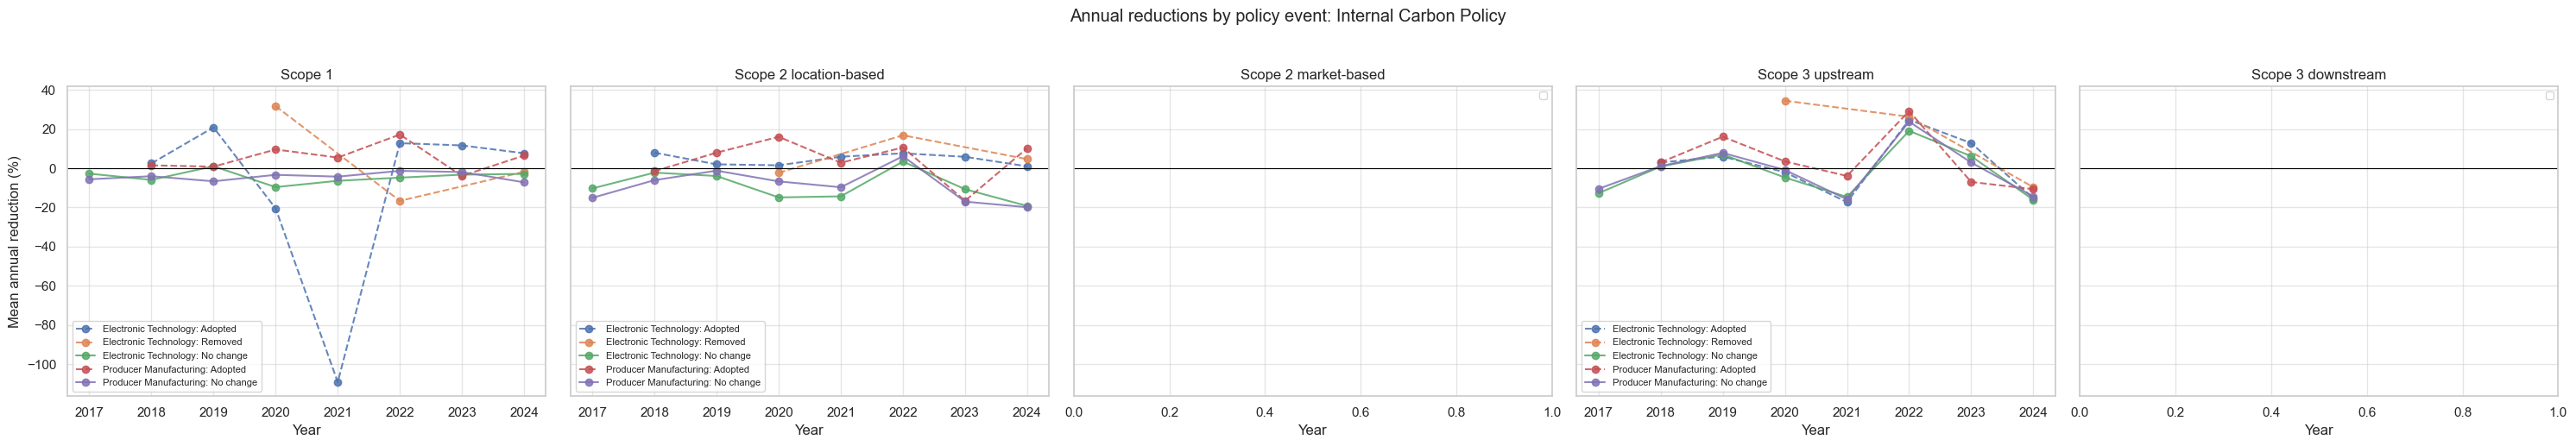

In [28]:
# Year-by-year visual for a policy selected here; change the value to inspect another policy.
POLICY_CHANGE_PLOT_FIELD = (
    "internal_carbon_policy" if "internal_carbon_policy" in HLM_POLICY_FIELDS else HLM_POLICY_FIELDS[0]
)
plot_data = policy_change_year_summary.query("policy_field == @POLICY_CHANGE_PLOT_FIELD")
display(plot_data.sort_values(["scope", "year", "SECTOR_DESC", "policy_event"]))
event_order = ["Adopted", "Removed", "No change"]
fig, axes = plt.subplots(1, len(EMISSION_COLUMNS), figsize=(6 * len(EMISSION_COLUMNS), 5), sharey=True)
for ax, scope in zip(np.atleast_1d(axes), EMISSION_COLUMNS):
    scope_data = plot_data[plot_data["scope"].eq(scope)]
    for sector in FOCUS_SECTORS:
        for event in event_order:
            series = scope_data[
                scope_data["SECTOR_DESC"].eq(sector) & scope_data["policy_event"].eq(event)
            ].sort_values("year")
            if not series.empty:
                ax.plot(
                    series["year"], series["mean_pct_reduction"], marker="o",
                    linestyle="-" if event == "No change" else "--",
                    label=f"{sector}: {event}", alpha=0.85,
                )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(scope)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean annual reduction (%)" if ax is np.atleast_1d(axes)[0] else "")
    ax.legend(fontsize=8)
fig.suptitle(f"Annual reductions by policy event: {POLICY_CHANGE_PLOT_FIELD.replace('_', ' ').title()}", y=1.03)
plt.tight_layout()
plt.show()


### Estimate policy-change regressions


,outcome,term,coefficient,std_error,p_value,ci_low,ci_high,n_rows,n_companies,policy_field,n_adoptions,n_removals,event
627,scope_1_absolute_emissions_log_reduction,policy_adopted__eco_design,0.002272,0.062614,0.971049,-0.120449,0.124993,5055,1085,eco_design,202,37,Adopted
642,scope_1_emissions_intensity_log_reduction,policy_adopted__eco_design,-0.001603,0.061930,0.979346,-0.122984,0.119777,5055,1085,eco_design,202,37,Adopted
657,scope_2_location_based_absolute_emissions_log_...,policy_adopted__eco_design,-0.021353,0.048166,0.657536,-0.115757,0.073051,5060,1086,eco_design,204,37,Adopted
672,scope_2_location_based_emissions_intensity_log...,policy_adopted__eco_design,-0.021829,0.045368,0.630415,-0.110749,0.067092,5060,1086,eco_design,204,37,Adopted
687,scope_3_upstream_absolute_emissions_log_reduction,policy_adopted__eco_design,0.006356,0.018594,0.732490,-0.030087,0.042798,5062,1087,eco_design,204,37,Adopted
...,...,...,...,...,...,...,...,...,...,...,...,...,...
911,scope_1_emissions_intensity_log_reduction,policy_adopted__transition_plan_offsets,-0.046857,0.036904,0.204187,-0.119187,0.025473,5052,1085,transition_plan_offsets,23,3,Adopted
925,scope_2_location_based_absolute_emissions_log_...,policy_adopted__transition_plan_offsets,0.124757,0.038333,0.001136,0.049625,0.199889,5057,1086,transition_plan_offsets,23,3,Adopted
939,scope_2_location_based_emissions_intensity_log...,policy_adopted__transition_plan_offsets,0.133313,0.039662,0.000776,0.055578,0.211048,5057,1086,transition_plan_offsets,23,3,Adopted
953,scope_3_upstream_absolute_emissions_log_reduction,policy_adopted__transition_plan_offsets,-0.006194,0.023844,0.795028,-0.052928,0.040539,5059,1087,transition_plan_offsets,23,3,Adopted


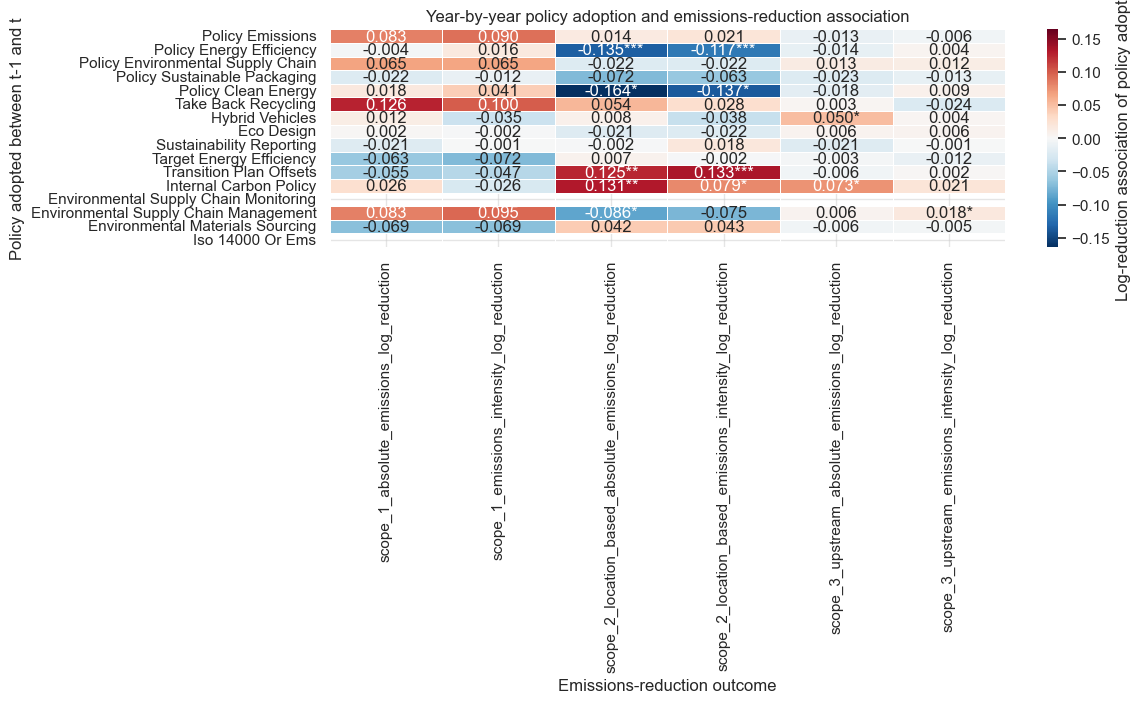

In [29]:
def fit_dynamic_policy_change(outcome: str, policy_field: str):
    if not HAS_STATSMODELS:
        return pd.DataFrame()
    adoption_column = f"policy_adopted__{policy_field}"
    removal_column = f"policy_removed__{policy_field}"
    columns = [
        outcome, COMPANY_ID, "year", "SECTOR_DESC", adoption_column, removal_column,
        *DYNAMIC_CONTROL_PREDICTORS,
    ]
    model_data = dynamic_panel[columns].copy()
    for column in [outcome, COMPANY_ID, "year", adoption_column, removal_column, *DYNAMIC_CONTROL_PREDICTORS]:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")
    model_data["SECTOR_DESC"] = model_data["SECTOR_DESC"].astype("string")
    model_data = model_data.dropna().copy()
    n_adoptions = int(model_data[adoption_column].sum())
    n_removals = int(model_data[removal_column].sum())
    if len(model_data) < 100 or model_data[COMPANY_ID].nunique() < 20 or n_adoptions < MIN_POLICY_ADOPTIONS:
        return pd.DataFrame()
    event_terms = [adoption_column]
    # Do not let a handful of removals become part of the reference group.
    if n_removals >= MIN_POLICY_ADOPTIONS:
        event_terms.append(removal_column)
    else:
        model_data = model_data[model_data[removal_column].eq(0)].copy()
    model_data[COMPANY_ID] = model_data[COMPANY_ID].astype("int64")
    model_data["year"] = model_data["year"].astype("int64")
    model_data["SECTOR_DESC"] = model_data["SECTOR_DESC"].astype(str)
    formula = f"{outcome} ~ {' + '.join([*event_terms, *DYNAMIC_CONTROL_PREDICTORS])} + C(year) + C(SECTOR_DESC)"
    try:
        result = smf.ols(formula, data=model_data).fit(
            cov_type="cluster", cov_kwds={"groups": model_data[COMPANY_ID]}
        )
    except Exception as exc:
        print(f"Dynamic model failed for {policy_field} / {outcome}: {type(exc).__name__}: {exc}")
        return pd.DataFrame()
    confidence = result.conf_int()
    table = pd.DataFrame({
        "outcome": outcome, "term": result.params.index,
        "coefficient": result.params.values, "std_error": result.bse.values,
        "p_value": result.pvalues.values,
        "ci_low": confidence.iloc[:, 0].values, "ci_high": confidence.iloc[:, 1].values,
        "n_rows": len(model_data), "n_companies": model_data[COMPANY_ID].nunique(),
        "policy_field": policy_field, "n_adoptions": n_adoptions, "n_removals": n_removals,
    })
    table["event"] = np.where(table["term"].eq(adoption_column), "Adopted", np.where(table["term"].eq(removal_column), "Removed", pd.NA))
    return table

RUN_DYNAMIC_POLICY_CHANGE_MODELS = True
dynamic_model_tables = []
if RUN_DYNAMIC_POLICY_CHANGE_MODELS:
    for policy_field in HLM_POLICY_FIELDS:
        for outcome in REDUCTION_OUTCOMES:
            table = fit_dynamic_policy_change(outcome, policy_field)
            if not table.empty:
                dynamic_model_tables.append(table)
dynamic_policy_change_coefficients = (
    pd.concat(dynamic_model_tables, ignore_index=True)
    if dynamic_model_tables else pd.DataFrame()
)
dynamic_policy_adoption_effects = (
    dynamic_policy_change_coefficients.query("event == 'Adopted'").copy()
    if not dynamic_policy_change_coefficients.empty else pd.DataFrame()
)
if dynamic_policy_adoption_effects.empty:
    print("No policy fields have enough adoption events for the dynamic regressions.")
else:
    display(dynamic_policy_adoption_effects.sort_values(["policy_field", "outcome"]))

    def stars(p_value):
        if pd.isna(p_value):
            return ""
        return "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""

    dynamic_matrix = (
        dynamic_policy_adoption_effects.pivot(index="policy_field", columns="outcome", values="coefficient")
        .reindex(index=HLM_POLICY_FIELDS, columns=REDUCTION_OUTCOMES)
    )
    dynamic_pvalues = (
        dynamic_policy_adoption_effects.pivot(index="policy_field", columns="outcome", values="p_value")
        .reindex(index=HLM_POLICY_FIELDS, columns=REDUCTION_OUTCOMES)
    )
    dynamic_annotations = dynamic_matrix.copy().astype(object)
    for policy_field in dynamic_matrix.index:
        for outcome in dynamic_matrix.columns:
            beta = dynamic_matrix.loc[policy_field, outcome]
            p_value = dynamic_pvalues.loc[policy_field, outcome]
            dynamic_annotations.loc[policy_field, outcome] = f"{beta:.3f}{stars(p_value)}" if pd.notna(beta) else ""
    dynamic_matrix.index = [field.replace("_", " ").title() for field in dynamic_matrix.index]
    dynamic_annotations.index = dynamic_matrix.index
    maximum = max(float(dynamic_matrix.abs().max().max()), 0.01)
    fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(dynamic_matrix))))
    sns.heatmap(
        dynamic_matrix, cmap="RdBu_r", center=0, vmin=-maximum, vmax=maximum,
        annot=dynamic_annotations, fmt="", linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Log-reduction association of policy adoption"}, ax=ax,
    )
    ax.set_title("Year-by-year policy adoption and emissions-reduction association")
    ax.set_xlabel("Emissions-reduction outcome")
    ax.set_ylabel("Policy adopted between t-1 and t")
    plt.tight_layout()
    plt.show()
